In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import pearsonr, spearmanr, chi2_contingency
from sklearn.metrics import pairwise_distances, cohen_kappa_score
import itertools
import string
from itertools import combinations


In [ ]:
df = pd.read_csv("knowledge_outputs.csv")

orig = df[df["Paraphrase"]==0][["Model","exposure","outcome","direction"]].rename(columns={"direction":"direction_orig"})
para = df[df["Paraphrase"]==1][["Model","factor1","factor2","direction"]].rename(columns={"factor1":"exposure","factor2":"outcome","direction":"direction_para"})

merged = orig.merge(para,on=["Model","exposure","outcome"],how="inner")
merged[["direction_orig","direction_para"]] = merged[["direction_orig","direction_para"]].apply(lambda x:x.str.strip().str.lower())

merged["disagreement"] = ((merged.direction_orig=="increase")&(merged.direction_para=="decrease")) | ((merged.direction_orig=="decrease")&(merged.direction_para=="increase"))
merged["agreement"] = ~merged["disagreement"]

agreement = merged.groupby("Model")["agreement"].agg(agreement="sum",total="count").assign(agreement_pct=lambda x:100*x.agreement/x.total).reset_index()

disagreements = merged[merged.disagreement][["Model","exposure","outcome","direction_orig","direction_para"]].sort_values(["Model","exposure","outcome"])

print("\nDIRECTIONAL AGREEMENT")
print(agreement.to_string(index=False))
print("\nTRUE DIRECTIONAL DISAGREEMENTS")
print(disagreements.to_string(index=False))


DIRECTIONAL AGREEMENT
          Model  agreement  total  agreement_pct
claudesonnet4.6         33     33     100.000000
  deepseek.v3.2         32     33      96.969697
   gpt-oss-120b         32     33      96.969697

TRUE DIRECTIONAL DISAGREEMENTS
        Model                                                         exposure                                      outcome direction_orig direction_para
deepseek.v3.2 non-injection routes of opioid administration (smoking/snorting) personal HCV infection status (RNA-positive)       decrease       increase
 gpt-oss-120b non-injection routes of opioid administration (smoking/snorting)                 non-fatal overdose incidence       increase       decrease


In [2]:
file = '2018-09-13--06.02.24.events.csv'
abm = pd.read_csv(file, header=4)

df = pd.read_csv("outputs.csv")
df["HCV_active"] = df["HCV"].str.lower().isin(["acute"]).astype(int)
df_f = df[df["Paraphrase"] == 0].copy()

measures = ["Overdose", "Public_prop", "Recept_sharing", "Partners", "Drug_in",
    "Drug_out", "Partner_HCV_prop", "Treatment",
    "Injections", "Alt_route", "HCV_active"]

C:\Users\yysma\AppData\Local\Temp\ipykernel_26064\3468549192.py:2: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  abm = pd.read_csv(file, header=4)


In [3]:
sampled_agents = np.array([
     490771391,  208393663, 1760779551, 1110995944, 2018099683,  700138803,
    1238160207, 1775692649, 2009710957, 1430711947,  100089119, 1269377113,
    1862137729,  162017053, 1783923110, 1567516885, 1213546922,  502647399,
     824065553, 1995743439, 1550207174,  317730658,  609466392, 1697243488,
     824791918,  502638095,  698846865,   63817574, 1995687921, 1275841472,
      26429671, 1120408643,  292324658, 1807218704, 1669344666, 1563664267,
     423011984, 1405832272, 2031006759, 1668563912,   79133241,  397268654,
    1395959888,  963081219,  711890032, 1720038860,  365001892, 1630256158,
    1460725667, 1772567691,  666622208,  585523389,  939022949, 1793500374,
     251775409, 1100205186,  129097015, 1893698573,  565200591, 1402976323,
    1030464062,    9327643,   51563394, 2033927730, 1286502092,  626733441,
    1022153274,  508778252, 1944693737,  648098819, 1836697781, 1400392138,
     491890135, 1968895262, 1098016259,  519435702, 1778475719, 1460282005,
     843028679,  275804893, 1100749583,  904610199,   13639810,  478908450,
    1448229649, 1975966814, 1030084260, 1491763478,   77885434, 2036455447,
     331584791, 1940495590, 1561600039,  267653958, 1392833177, 1743186553,
     575659903,  896749098,  693664342,   35575092, 1771078787,   27796450,
     473890045, 1907522214, 1818777435,  631389276,  619892608,  677437369,
     576592276, 2042962245, 1764432037,  832666603,

    1363458668,  618736064, 2045502604, 1702173449, 1447776376, 1744176741,
    1220931314, 1631093824, 1206809341, 1542231393, 1686954479, 2036864642,
    1328373163,  945538622, 1292814647, 1405904323, 2067883326,  579366849,
     364076346, 1920727937,  159851843, 1469241060,  912580702, 1915447867,
     458535663,  948910005, 1063464511,  821627210,  668556780, 1199716571,
    1291175758, 1174634703,  101383680, 2017573802, 1088430014,  438837827,
    1474368929, 2047833866, 2011031237,  680703945,  676737501, 2068127024,
     994019246, 2005055216, 1710548080,  724657989, 1600776702,  144098857,
     803017132,  769741880,  509596509,  888820495, 1202943946,  947802954,
    1778090979, 1284023361, 1699509272,  428383452, 1885795516, 1372621296,
    1339309556, 1436821634,  908269962, 1681328653, 1764549651, 1547276296,
    2021178250,  737889447, 1674453744,  733690094, 1150095185, 1248369296,
     883445275, 1449170244,   19089357,  764490345,  726965997, 1522828346,
    1840229486,  876608218, 1397638301,  766099189, 1096898509, 2010264360,
    1895476383,  316352317, 2004480369, 1598509245, 1227991065,  692250571,
     473592046, 1043963840,  968444565, 1584652614,  993482057, 1716903627,
      31194719, 2106396788, 1545695174, 1325982765,  995433015,  797506870,
    1641236707, 1683945314, 1869276942,  934277407,  452709452, 1591838336,
    2107797130,  729620191, 1318481682,  725442634
])

ABM COMPARISON

In [4]:
abm = abm[abm["Agent"].isin(sampled_agents)].copy()
zip_lookup = abm.groupby("Agent")["Zip"].first().reset_index()

TIME_COL = "Time"
VALID_HCV = ["acute", "chronic", "susceptible", "exposed", "recovered"]

abm = abm[abm["HCV"].astype(str).isin(VALID_HCV)].copy()
abm["HCV_binary"] = (abm["HCV"].astype(str).isin(["acute", "chronic"]).astype(int))

# compute first observation time per agent
first_times = (abm.groupby("Agent", as_index=False)[TIME_COL].min()
    .rename(columns={TIME_COL: "first_time"}))

abm = abm.merge(first_times, on="Agent", how="left")
assert "first_time" in abm.columns
abm["target_time"] = abm["first_time"] + 0.5 # agent-specific target time
abm_followup = abm[abm[TIME_COL] != abm["first_time"]].copy() # remove initial observation

# compute distance to each agent-specific target
abm_followup["time_diff"] = (
    abm_followup[TIME_COL] - abm_followup["target_time"]).abs()

snapshot = (abm_followup.sort_values(["Agent", "time_diff"])
    .groupby("Agent", as_index=False).first())

snapshot = snapshot[["Agent", "HCV", TIME_COL, "first_time",
    "Daily_injection_intensity", "Fraction_recept_sharing",
    "Drug_in_degree", "Drug_out_degree", "HCV_friend_preval"]].rename(columns={TIME_COL: "Time_used"})
abm_agg = snapshot.copy()

abm_agg["Recept_sharing"] = abm_agg["Fraction_recept_sharing"]
abm_agg["Drug_in"] = abm_agg["Drug_in_degree"]
abm_agg["Drug_out"] = abm_agg["Drug_out_degree"]
abm_agg["Injections"] = abm_agg["Daily_injection_intensity"] * 7
abm_agg["Partner_HCV_prop"] = abm_agg["HCV_friend_preval"]

abm_agg["HCV_active"] = (abm_agg["HCV"].astype(str).str.lower()
    .isin(["acute", "chronic"]).astype(int))

snapshot["actual_diff"] = snapshot["Time_used"] - snapshot["first_time"]
snapshot["actual_diff"].describe()

count    224.000000
mean       3.966134
std        2.805098
min        0.046000
25%        1.586500
50%        3.506500
75%        6.192250
max        9.750000
Name: actual_diff, dtype: float64

checking whether time restriction matters

 tolerance  n_kept  mean_ccc  mean_rho  pct_change_ccc
     10.00     224  0.739590  0.807302             NaN
      5.00     155  0.748987  0.824143        1.270502
      2.00      85  0.767486  0.846317        2.469873
      1.00      53  0.758528  0.828746       -1.167088
      0.50      43  0.781587  0.856687        3.039848
      0.25      27  0.825861  0.879357        5.664682
      0.10      14  0.783670  0.826247       -5.108720


C:\Users\yysma\AppData\Local\Temp\ipykernel_26064\3957064255.py:106: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.05, 1, 0.93])


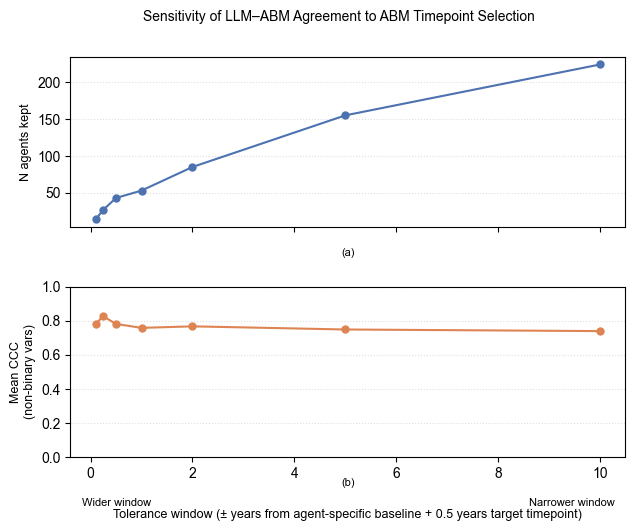

In [9]:
def concordance_corr_coef(x, y):
    x, y = np.asarray(x), np.asarray(y)
    mean_x, mean_y = x.mean(), y.mean()
    var_x, var_y = x.var(), y.var()
    cov_xy = np.mean((x - mean_x) * (y - mean_y))
    return (2 * cov_xy) / (var_x + var_y + (mean_x - mean_y) ** 2)

non_binary_vars = ["Injections", "Recept_sharing", "Drug_in", "Drug_out", "Partner_HCV_prop"]
agent_housing = df_f.sort_values("Agent").drop_duplicates("Agent")[["Agent", "Homeless"]]

tolerances = [10, 5, 2, 1, 0.5, 0.25, 0.1]
sweep_rows = []

for tol in tolerances:
    low, high = max(0, 0.5 - tol), 0.5 + tol
    in_window = (snapshot["actual_diff"] >= low) & (snapshot["actual_diff"] <= high)
    snap_sub = snapshot[in_window].copy()
    n_kept = len(snap_sub)

    diff_check = snapshot.assign(in_window=in_window).merge(agent_housing, on="Agent", how="left")
    contingency = pd.crosstab(diff_check["Homeless"], diff_check["in_window"])

    if n_kept < 10:
        sweep_rows.append({
            "tolerance": tol,
            "n_kept": n_kept,
            "mean_ccc": np.nan,
            "mean_rho": np.nan,})
        continue

    abm_agg_tol = snap_sub.merge(zip_lookup, on="Agent", how="left")
    abm_agg_tol["Injections"] = abm_agg_tol["Daily_injection_intensity"] * 7
    abm_agg_tol["Recept_sharing"] = abm_agg_tol["Fraction_recept_sharing"]
    abm_agg_tol["Drug_in"] = abm_agg_tol["Drug_in_degree"]
    abm_agg_tol["Drug_out"] = abm_agg_tol["Drug_out_degree"]
    abm_agg_tol["Partner_HCV_prop"] = abm_agg_tol["HCV_friend_preval"]

    abm_agg_tol_renamed = abm_agg_tol[
        ["Agent", "Injections", "Recept_sharing", "Drug_in", "Drug_out", "Partner_HCV_prop"]
    ].rename(columns={**{c: f"ABM_{c}" for c in non_binary_vars}})

    ccc_vals, rho_vals = [], []
    kappa_vals, sens_vals, spec_vals = [], [], []

    for model in df_f["Model"].unique():
        for homeless_val in sorted(df_f["Homeless"].unique()):
            sub = df_f[(df_f["Model"] == model) & (df_f["Homeless"] == homeless_val)]
            merged = sub.merge(abm_agg_tol_renamed, on="Agent", how="inner")
            if len(merged) < 10:
                continue

            # non_binary variables: CCC and Spearman’s rho
            for var in non_binary_vars:
                llm_vals, abm_vals = merged[var], merged[f"ABM_{var}"]
                if llm_vals.nunique() > 1 and abm_vals.nunique() > 1:
                    rho, _ = spearmanr(llm_vals, abm_vals)
                    ccc_vals.append(concordance_corr_coef(llm_vals.values, abm_vals.values))
                    rho_vals.append(rho)

    sweep_rows.append({
        "tolerance": tol,
        "n_kept": n_kept,
        "mean_ccc": np.nanmean(ccc_vals),
        "mean_rho": np.nanmean(rho_vals),})

sweep_df = pd.DataFrame(sweep_rows)
sweep_df = sweep_df.sort_values("tolerance", ascending=False).reset_index(drop=True)
sweep_df["pct_change_ccc"] = sweep_df["mean_ccc"].pct_change() * 100
print(sweep_df.to_string(index=False))

# --- FIGURE ---

plt.rcParams["font.family"] = "Arial"
fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(7.16, 5.2), sharex=True, gridspec_kw={"hspace": 0.35})

ax1.plot(sweep_df["tolerance"], sweep_df["n_kept"],
         color="#4C72B0", marker="o", markersize=5)
ax1.set_ylabel("N agents kept", fontsize=9)
ax1.grid(axis="y", linestyle=":", alpha=0.4)

ax2.plot(sweep_df["tolerance"], sweep_df["mean_ccc"],
         color="#DD8452", marker="o", markersize=5)
ax2.set_ylabel("Mean CCC\n(non-binary vars)", fontsize=9)
ax2.set_ylim(0, 1)
ax2.set_xlabel("Tolerance window (± years from agent-specific baseline + 0.5 years target timepoint)",
               fontsize=9, labelpad=20)
ax2.grid(axis="y", linestyle=":", alpha=0.4)

ax2.grid(axis="y", linestyle=":", alpha=0.4)
for ax in (ax1, ax2):
    ax.invert_xaxis()
ax2.text(0.02, -0.24, "Wider window", transform=ax2.transAxes,
         ha="left", va="top", fontsize=8)
ax2.text(0.98, -0.24, "Narrower window", transform=ax2.transAxes,
         ha="right", va="top", fontsize=8)

label_y_positions = [-0.12, -0.12, -0.22]
for ax, label, y_pos in zip([ax1, ax2], ["a", "b", "c"], label_y_positions):
    ax.text(0.5, y_pos, f"({label})", transform=ax.transAxes,
            ha="center", va="top", fontsize=8, fontname="Arial")

fig.suptitle("Sensitivity of LLM–ABM Agreement to ABM Timepoint Selection",
             fontsize=10, y=0.97)

plt.tight_layout(rect=[0, 0.05, 1, 0.93])
plt.savefig("figures/tolerance_sweep.pdf", bbox_inches="tight", dpi=300)

In [11]:
abm_agg = abm_agg.copy()
abm_agg_renamed = abm_agg[
    ["Agent", "Injections", "Recept_sharing", "Drug_in", "Drug_out", "Partner_HCV_prop"]
].rename(columns={
        "Injections": "ABM_Injections",
        "Recept_sharing": "ABM_Recept_sharing",
        "Drug_in": "ABM_Drug_in",
        "Drug_out": "ABM_Drug_out",
        "Partner_HCV_prop": "ABM_Partner_HCV_prop",})

results = []
compare_cols = ["Injections", "Recept_sharing", "Drug_in", "Drug_out", "Partner_HCV_prop"]

# flatten upper triangle of correlation matrix
def flatten_corr(corr):
    v = corr.values
    return v[np.triu_indices_from(v, k=1)]

for model in df_f["Model"].unique():
    for housing in df_f["Homeless"].unique():

        sub = df_f[(df_f["Model"] == model) &
            (df_f["Homeless"] == housing)]
        merged = sub.merge(abm_agg_renamed, on="Agent")

        llm_sub = merged[compare_cols]
        abm_sub = merged[["ABM_Injections", "ABM_Recept_sharing",
             "ABM_Drug_in", "ABM_Drug_out", "ABM_Partner_HCV_prop"]].copy()
        abm_sub.columns = compare_cols

        # correlation matrices
        abm_corr = abm_sub.corr(method="spearman")
        llm_corr = llm_sub.corr(method="spearman")

        # flatten correlation matrices
        abm_vec = flatten_corr(abm_corr)
        llm_vec = flatten_corr(llm_corr)

        # mean absolute difference between correlation structures
        mask = ~np.isnan(abm_vec) & ~np.isnan(llm_vec)
        mean_corr_difference = np.mean(np.abs(abm_vec[mask] - llm_vec[mask]))

        # individual pairwise associations
        abm_pairs = {f"{x}__{y}": abm_corr.loc[x, y]
            for x, y in combinations(compare_cols, 2)}

        llm_pairs = {f"{x}__{y}": llm_corr.loc[x, y]
            for x, y in combinations(compare_cols, 2)}

        results.append({
            "Model": model,
            "Housing": housing,
            "mean_corr_difference": mean_corr_difference,
            **{f"assoc_LLM_{k}": v for k, v in llm_pairs.items()},
            **{f"assoc_ABM_{k}": v for k, v in abm_pairs.items()},})

results_df = pd.DataFrame(results)
print(results_df)

             Model  Housing  mean_corr_difference  \
0  claudesonnet4.6        1              0.098139   
1  claudesonnet4.6        0              0.114263   
2    deepseek.v3.2        1              0.124667   
3    deepseek.v3.2        0              0.127674   
4     gpt-oss-120b        1              0.126956   
5     gpt-oss-120b        0              0.129096   

   assoc_LLM_Injections__Recept_sharing  assoc_LLM_Injections__Drug_in  \
0                              0.087901                       0.276776   
1                              0.122167                       0.291387   
2                              0.214239                       0.291662   
3                              0.210010                       0.307367   
4                              0.083441                       0.277724   
5                              0.043809                       0.298319   

   assoc_LLM_Injections__Drug_out  assoc_LLM_Injections__Partner_HCV_prop  \
0                        0.18080

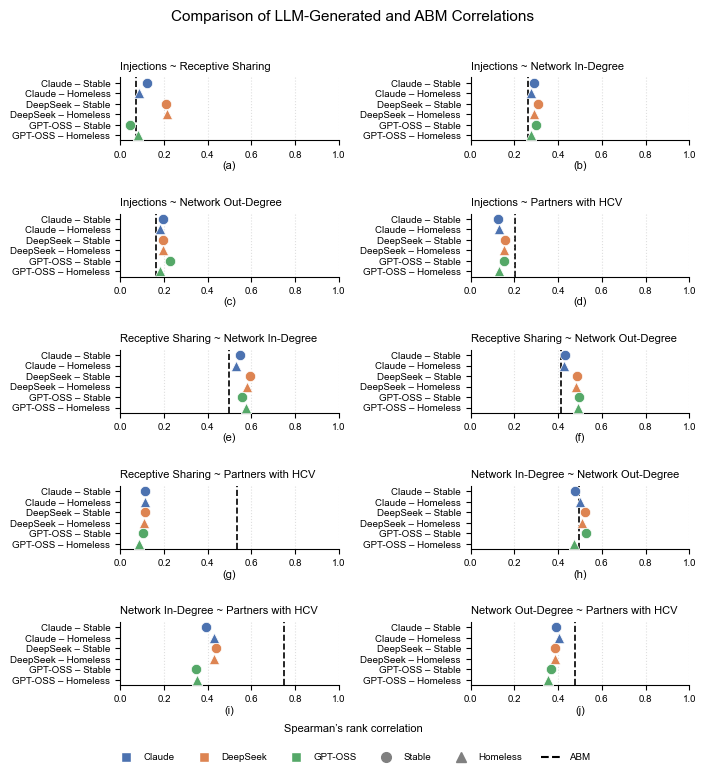

In [25]:
plt.rcParams["font.family"] = "Arial"

plot_df = results_df.copy()
plot_df["Homeless"] = plot_df["Housing"].map({0: "Stable", 1: "Homeless"})
plot_df["Model"] = plot_df["Model"].replace({
    "claudesonnet4.6": "Claude",
    "deepseek.v3.2": "DeepSeek",
    "gpt-oss-120b": "GPT-OSS",
})

model_order = ["Claude", "DeepSeek", "GPT-OSS"]
homeless_order = ["Stable", "Homeless"]

plot_df["Model"] = pd.Categorical(plot_df["Model"], categories=model_order, ordered=True)
plot_df["Homeless"] = pd.Categorical(plot_df["Homeless"], categories=homeless_order, ordered=True)

plot_df["Label"] = plot_df["Model"].astype(str) + " – " + plot_df["Homeless"].astype(str)
order = plot_df.sort_values(["Model", "Homeless"])["Label"].drop_duplicates().tolist()
plot_df["Label"] = pd.Categorical(plot_df["Label"], categories=order, ordered=True)
plot_df = plot_df.sort_values("Label").reset_index(drop=True)

model_colors = {"Claude": "#4C72B0", "DeepSeek": "#DD8452", "GPT-OSS": "#55A868"}
housing_markers = {"Stable": "o", "Homeless": "^"}

compare_cols = ["Injections", "Recept_sharing", "Drug_in", "Drug_out", "Partner_HCV_prop"]
pretty_names = {
    "Injections": "Injections",
    "Recept_sharing": "Receptive Sharing",
    "Drug_in": "Network In-Degree",
    "Drug_out": "Network Out-Degree",
    "Partner_HCV_prop": "Partners with HCV",
}

metrics = []
for x, y in combinations(compare_cols, 2):
    llm_col = f"assoc_LLM_{x}__{y}"
    abm_col = f"assoc_ABM_{x}__{y}"
    title = f"{pretty_names[x]} ~ {pretty_names[y]}"
    metrics.append((llm_col, abm_col, title))

n_rows = 5
n_cols = 2
fig_width = 7.16
fig_height = 7.5

fig, axes = plt.subplots(n_rows, n_cols, figsize=(fig_width, fig_height), sharex=False)
axes = axes.flatten()

y = np.arange(len(plot_df))
subfig_labels = list(string.ascii_lowercase)

for i, (ax, (llm_col, abm_col, title)) in enumerate(zip(axes, metrics)):
    abm_value = plot_df[abm_col].iloc[0]
    ax.axvline(abm_value, color="black", linestyle="--", linewidth=1.2, zorder=1, label="ABM")

    for model, sub in plot_df.groupby("Model", observed=True):
        for housing, sub2 in sub.groupby("Homeless", observed=True):
            idx = sub2.index
            ax.scatter(plot_df.loc[idx, llm_col], y[idx], color=model_colors[model],
                marker=housing_markers[housing], s=55, edgecolor="white", linewidth=0.5, zorder=3,)

    ax.set_yticks(y)
    ax.set_yticklabels(plot_df["Label"], fontsize=7)
    ax.set_ylim(-0.5, len(plot_df) - 0.5)
    ax.invert_yaxis()
    ax.set_title(title, fontsize=8, loc="left")
    ax.set_xlim(0, 1)
    ax.grid(axis="x", linestyle=":", alpha=0.4)
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(labelsize=7)
    ax.text(0.5, -0.32, f"({subfig_labels[i]})", transform=ax.transAxes,
        ha="center", va="top", fontsize=8, fontname="Arial",)

model_handles = [plt.Line2D([0], [0], marker="s", color="w", markerfacecolor=c, markersize=7, label=m)
    for m, c in model_colors.items()]
housing_handles = [plt.Line2D([0], [0], marker=mk, color="gray", linestyle="", markersize=7, label=h)
    for h, mk in housing_markers.items()]
abm_handle = [plt.Line2D([0], [0], color="black", linestyle="--", label="ABM")]

fig.supxlabel("Spearman’s rank correlation", fontsize=8, y=0.045)

fig.legend(handles=model_handles + housing_handles + abm_handle, loc="lower center",
    ncol=6, frameon=False, fontsize=7, bbox_to_anchor=(0.5, -0.005),)

fig.suptitle("Comparison of LLM-Generated and ABM Correlations", fontsize=11, y=1.01)

plt.tight_layout(rect=[0, 0, 1, 1])

plt.savefig("figures/abm_corr.pdf", bbox_inches="tight")

HCV individual-level analysis

In [140]:

results_hcv_by_homeless = []

for model in df_f["Model"].unique():
    df_m = df_f[df_f["Model"] == model].copy()

    df_agent_hcv = (
        df_m.sort_values("Agent")
        .drop_duplicates(["Agent", "Homeless"])[["Agent", "HCV", "Homeless"]]
        .rename(columns={"HCV": "LLM_HCV"}))

    abm_hcv = abm_agg[["Agent", "HCV_active"]].copy()
    merged_hcv = df_agent_hcv.merge(abm_hcv, on="Agent", how="inner")

    merged_hcv["LLM_HCV_active"] = (merged_hcv["LLM_HCV"].astype(str).str.lower()
                                    .isin(["acute", "chronic"]).astype(int))
    merged_hcv["match_hcv"] = merged_hcv["LLM_HCV_active"] == merged_hcv["HCV_active"]

    for homeless_val in sorted(merged_hcv["Homeless"].unique()):
        sub = merged_hcv[merged_hcv["Homeless"] == homeless_val]

        kappa = cohen_kappa_score(sub["LLM_HCV_active"], sub["HCV_active"])
        abm_prevalence = sub["HCV_active"].mean()
        llm_prevalence = sub["LLM_HCV_active"].mean()
        match_rate = sub["match_hcv"].mean()

        pos = sub[sub["HCV_active"] == 1]
        sensitivity = pos["LLM_HCV_active"].mean() if len(pos) > 0 else float("nan")
        n_pos = len(pos)

        neg = sub[sub["HCV_active"] == 0]
        specificity = (1 - neg["LLM_HCV_active"]).mean() if len(neg) > 0 else float("nan")
        n_neg = len(neg)

        results_hcv_by_homeless.append({
            "model": model,
            "homeless": homeless_val,
            "match_rate": match_rate,
            "kappa": kappa,
            "abm_prevalence": abm_prevalence,
            "llm_prevalence": llm_prevalence,
            "sensitivity": sensitivity,
            "n_pos": n_pos,
            "specificity": specificity,
            "n_neg": n_neg,})

summary_hcv_homeless = pd.DataFrame(results_hcv_by_homeless)
print(summary_hcv_homeless)

             model  homeless  match_rate     kappa  abm_prevalence  \
0  claudesonnet4.6         0    0.906250  0.059200        0.084821   
1  claudesonnet4.6         1    0.883929  0.214883        0.084821   
2    deepseek.v3.2         0    0.897321  0.040953        0.084821   
3    deepseek.v3.2         1    0.875000  0.109850        0.084821   
4     gpt-oss-120b         0    0.794643  0.183906        0.084821   
5     gpt-oss-120b         1    0.825893  0.228541        0.084821   

   llm_prevalence  sensitivity  n_pos  specificity  n_neg  
0        0.017857     0.052632     19     0.985366    205  
1        0.075893     0.263158     19     0.941463    205  
2        0.026786     0.052632     19     0.975610    205  
3        0.066964     0.157895     19     0.941463    205  
4        0.200893     0.473684     19     0.824390    205  
5        0.169643     0.473684     19     0.858537    205  


Among agents that the LLM predicted as HCV-positive but was ABM HCV-negative at the matched timepoint, did the agent become ABM HCV-positive at any point in that agent's trajectory?

In [95]:
summary_results = []

# ABM HCV status at the agent-specific target timepoint
abm_matched = (abm_agg[["Agent", "HCV_active"]]
    .rename(columns={"HCV_active": "ABM_HCV_6mo"}))

# ABM entire trajectory (ever infected)
abm_trajectory = (abm.groupby("Agent", as_index=False)["HCV_binary"].max()
    .rename(columns={"HCV_binary": "ABM_HCV_ever"}))

for model in df_f["Model"].unique():
    for housing in df_f["Homeless"].unique():
        llm = (
            df_f[
                (df_f["Model"] == model) &
                (df_f["Homeless"] == housing)
            ][["Agent", "HCV_active"]]
            .rename(columns={"HCV_active": "LLM_HCV"}))
        comparison = (
            llm
            .merge(abm_matched, on="Agent")
            .merge(abm_trajectory, on="Agent"))

        llm_positive = comparison[comparison["LLM_HCV"] == 1] # LLM-positive agents
        discordant = llm_positive[llm_positive["ABM_HCV_6mo"] == 0] # LLM-negative agents at matched timepoint
        n_eventually_matching = (discordant["ABM_HCV_ever"] == 1).sum() # sum of ABM-positive agent

        summary_results.append({
            "Model": model,
            "Housing": housing,
            "n_LLM_HCV_positive": len(llm_positive),
            "n_discordant_matched": len(discordant),
            "agreement_rate_matched": (
                1 - len(discordant) / len(llm_positive)
                if len(llm_positive) > 0 else np.nan),
            "n_eventually_ABM_positive": n_eventually_matching,
            "proportion_trajectory_compatible": (
                n_eventually_matching / len(llm_positive)
                if len(llm_positive) > 0 else np.nan),})

summary_df = pd.DataFrame(summary_results)
print(summary_df)

             Model  Housing  n_LLM_HCV_positive  n_discordant_matched  \
0  claudesonnet4.6        1                  17                    12   
1  claudesonnet4.6        0                   4                     3   
2    deepseek.v3.2        1                  15                    12   
3    deepseek.v3.2        0                   6                     5   
4     gpt-oss-120b        1                  38                    29   
5     gpt-oss-120b        0                  45                    36   

   agreement_rate_matched  n_eventually_ABM_positive  \
0                0.294118                          7   
1                0.250000                          3   
2                0.200000                          5   
3                0.166667                          2   
4                0.236842                         15   
5                0.200000                         15   

   proportion_trajectory_compatible  
0                          0.411765  
1                  

Among agents that the LLM predicted as HCV-negative, how many were ABM HCV-positive at the matched timepoint, and how many were ABM HCV-positive at any point in their trajectory?

In [ ]:
summary_results = []

abm_matched = (abm_agg[["Agent", "HCV_active"]]
    .rename(columns={"HCV_active": "ABM_HCV_matched"}))

abm_trajectory = (abm.groupby("Agent", as_index=False)["HCV_binary"].max()
    .rename(columns={"HCV_binary": "ABM_HCV_trajectory"}))

for model in df_f["Model"].unique():
    for housing in df_f["Homeless"].unique():
        llm_negative = (
            df_f[
                (df_f["Model"] == model) &
                (df_f["Homeless"] == housing) &
                (df_f["HCV_active"] == 0)
            ][["Agent"]])
        comparison = (
            llm_negative
            .merge(abm_matched, on="Agent")
            .merge(abm_trajectory, on="Agent"))
        summary_results.append({
            "Model": model,
            "Housing": housing,
            "n_LLM_HCV_negative": len(comparison),
            "ABM_HCV_positive_matched": comparison["ABM_HCV_matched"].sum(),
            "ABM_HCV_positive_ever": comparison["ABM_HCV_trajectory"].sum(),
            "proportion_ABM_positive_matched": comparison["ABM_HCV_matched"].mean(),
            "proportion_ABM_positive_ever": comparison["ABM_HCV_trajectory"].mean(),})

summary_negative = pd.DataFrame(summary_results)
print(summary_negative)

             Model  Housing  n_LLM_HCV_negative  ABM_HCV_positive_matched  \
0  claudesonnet4.6        1                 207                        14   
1  claudesonnet4.6        0                 220                        18   
2    deepseek.v3.2        1                 209                        16   
3    deepseek.v3.2        0                 218                        18   
4     gpt-oss-120b        1                 186                        10   
5     gpt-oss-120b        0                 179                        10   

   ABM_HCV_positive_ever  proportion_ABM_positive_matched  \
0                     52                         0.067633   
1                     60                         0.081818   
2                     56                         0.076555   
3                     61                         0.082569   
4                     40                         0.053763   
5                     40                         0.055866   

   proportion_ABM_positive_ever 

ABM HCV summary for sampled agents

In [97]:
abm = abm.copy()
abm["HCV_binary"] = (abm["HCV"].astype(str).isin(["acute", "chronic"]).astype(int))

sampled_ids = df_f["Agent"].unique()

trajectory_summary = (abm[abm["Agent"].isin(sampled_ids)]
    .groupby("Agent")["HCV_binary"].max().reset_index(name="ever_HCV"))

matched_summary = (abm_agg[["Agent", "HCV_active"]]
    .rename(columns={"HCV_active": "matched_HCV"}))

hcv_summary = trajectory_summary.merge(matched_summary, on="Agent", how="inner")
summary = pd.DataFrame({
    "n_agents": [len(hcv_summary)],
    "ever_HCV_positive_n": [hcv_summary["ever_HCV"].sum()],
    "ever_HCV_positive_prop": [hcv_summary["ever_HCV"].mean()],
    "matched_HCV_positive_n": [hcv_summary["matched_HCV"].sum()],
    "matched_HCV_positive_prop": [hcv_summary["matched_HCV"].mean()],
    "agents_never_HCV_positive_n": [(hcv_summary["ever_HCV"] == 0).sum()],
    "agents_never_HCV_positive_prop": [(hcv_summary["ever_HCV"] == 0).mean()]})

print(summary)

   n_agents  ever_HCV_positive_n  ever_HCV_positive_prop  \
0       224                   64                0.285714   

   matched_HCV_positive_n  matched_HCV_positive_prop  \
0                      19                   0.084821   

   agents_never_HCV_positive_n  agents_never_HCV_positive_prop  
0                          160                        0.714286  


HOUSING EFFECT ANALYSIS

In [145]:
def paired_bootstrap_with_d(df, outcome_col, agent_col="Agent", condition_col="Homeless",
    n_boot=1000, seed=42):
    np.random.seed(seed)
    wide = df.pivot(
        index=agent_col,
        columns=condition_col,
        values=outcome_col).dropna()

    agents = wide.index.values
    boot_means = []
    boot_ds = []

    for _ in range(n_boot):
        sampled_agents = np.random.choice(agents, size=len(agents), replace=True)
        sample = wide.loc[sampled_agents]

        diff = sample[1] - sample[0] # paired difference
        mean_diff = diff.mean()

        sd_diff = diff.std(ddof=1)
        d = mean_diff / (sd_diff + 1e-8)

        boot_ds.append(d)
    boot_ds = np.array(boot_ds) # paired cohens d, length 1000

    diff_full = wide[1] - wide[0]
    mean_diff_full = diff_full.mean()
    d_full = mean_diff_full / (diff_full.std(ddof=1) + 1e-8)

    return {
        "estimate": mean_diff_full,
        "cohens_d": d_full,
        "d_ci_lower": np.percentile(boot_ds, 2.5),
        "d_ci_upper": np.percentile(boot_ds, 97.5),}

In [ ]:
all_results = []

for model_name, df_m in df_f.groupby("Model"):
    for v in measures:
        res = paired_bootstrap_with_d(df_m, outcome_col=v)

        all_results.append({
            "Model": model_name,
            "Variable": v,
            "Paraphrase": 0,
            "Cohens_d": res["cohens_d"],
            "d_CI_lower": res["d_ci_lower"],
            "d_CI_upper": res["d_ci_upper"],})

results_df = pd.DataFrame(all_results)
results_df = results_df.sort_values(["Paraphrase", "Model", "Cohens_d"], ascending=[True, True, False])
print(results_df)

              Model          Variable  Paraphrase  Cohens_d  d_CI_lower  \
1   claudesonnet4.6       Public_prop           0  5.895803    5.374011   
0   claudesonnet4.6          Overdose           0  0.647614    0.499905   
2   claudesonnet4.6    Recept_sharing           0  0.365741    0.293977   
10  claudesonnet4.6        HCV_active           0  0.247662    0.179204   
4   claudesonnet4.6           Drug_in           0  0.113917    0.000000   
5   claudesonnet4.6          Drug_out           0  0.109519    0.000000   
6   claudesonnet4.6  Partner_HCV_prop           0  0.066815    0.000000   
3   claudesonnet4.6          Partners           0  0.040880   -0.063820   
8   claudesonnet4.6        Injections           0  0.028767   -0.105343   
7   claudesonnet4.6         Treatment           0  0.000000    0.000000   
9   claudesonnet4.6         Alt_route           0 -0.242365   -0.357557   
12    deepseek.v3.2       Public_prop           0  1.483831    1.291911   
21    deepseek.v3.2      

CORRELATIONS

In [150]:
all_results = []

for model_name, df_model in df_f.groupby("Model"):
    results = []

    for a, b in itertools.combinations(measures, 2):
        df_xy = pd.concat([df_model[a], df_model[b]], axis=1).dropna()
        x = df_xy.iloc[:, 0]
        y = df_xy.iloc[:, 1]
        if x.nunique() < 2 or y.nunique() < 2:
            corr = np.nan
        else:
            corr = x.corr(y, method="spearman")

        results.append({"model": model_name,
            "var1": a,
            "var2": b,
            "correlation": corr})

    all_results.append(pd.DataFrame(results))

corr_df = pd.concat(all_results, ignore_index=True)
model_order = ["claudesonnet4.6", "deepseek.v3.2", "gpt-oss-120b"]

def fmt_val_with_ci(val_str):
    clean_val = val_str.strip()
    try:
        v = float(clean_val.split('(')[0].strip())
        arrow = "↑" if v > 0 else ("↓" if v < 0 else "—")
    except ValueError:
        arrow = "—"
    if clean_val.lower() in ("nan", "") or clean_val == "—":
        return "—\n( , )"
    return f"{arrow} {clean_val}"

EXTRA_COLS_DATA = {}
for (var1, var2), g in corr_df.groupby(["var1", "var2"]):
    g = g.set_index("model").reindex(model_order)
    vals = g["correlation"].tolist()
    EXTRA_COLS_DATA[(var1, var2)] = [
        fmt_val_with_ci("NaN") if pd.isna(v) else fmt_val_with_ci(f"{v:.3f}")
        for v in vals]
EXTRA_COLS_DATA

{('Alt_route', 'HCV_active'): ['↑ 0.047', '↑ 0.115', '↑ 0.100'],
 ('Drug_in', 'Alt_route'): ['↑ 0.176', '↑ 0.238', '↑ 0.095'],
 ('Drug_in', 'Drug_out'): ['↑ 0.488', '↑ 0.516', '↑ 0.500'],
 ('Drug_in', 'HCV_active'): ['↑ 0.245', '↑ 0.197', '↑ 0.443'],
 ('Drug_in', 'Injections'): ['↑ 0.284', '↑ 0.299', '↑ 0.288'],
 ('Drug_in', 'Partner_HCV_prop'): ['↑ 0.411', '↑ 0.434', '↑ 0.349'],
 ('Drug_in', 'Treatment'): ['—\n( , )', '—\n( , )', '↓ -0.125'],
 ('Drug_out', 'Alt_route'): ['↑ 0.111', '↑ 0.158', '↑ 0.083'],
 ('Drug_out', 'HCV_active'): ['↑ 0.170', '↑ 0.074', '↑ 0.398'],
 ('Drug_out', 'Injections'): ['↑ 0.188', '↑ 0.194', '↑ 0.205'],
 ('Drug_out', 'Partner_HCV_prop'): ['↑ 0.398', '↑ 0.385', '↑ 0.360'],
 ('Drug_out', 'Treatment'): ['—\n( , )', '—\n( , )', '↓ -0.134'],
 ('Injections', 'Alt_route'): ['↑ 0.849', '↓ -0.073', '↑ 0.447'],
 ('Injections', 'HCV_active'): ['↑ 0.131', '↑ 0.108', '↑ 0.181'],
 ('Overdose', 'Alt_route'): ['↑ 0.621', '—\n( , )', '↑ 0.163'],
 ('Overdose', 'Drug_in'): ['↑

BASELINE TO OUTPUT

In [151]:
baseline_vars = {
    "prior_injection": "Prev_Injection",
    "prior_sharing": "Prev_recept_sharing",
    "prior_network": "Prev_friend_entry",
    "prior_drug_in": "Prev_Drug_in",
    "prior_drug_out": "Prev_Drug_out"}

output_vars = {
    "prior_injection": "Injections",
    "prior_sharing": "Recept_sharing",
    "prior_network": "Partner_HCV_prop",
    "prior_drug_in": "Drug_in",
    "prior_drug_out": "Drug_out"}

results = []

for model_name, df_m in df_f.groupby("Model"):
    for key in baseline_vars:
        base = baseline_vars[key]
        out = output_vars[key]

        sub = df_m[[base, out]].dropna().copy()
        change = sub[out] - sub[base]

        mean_change = change.mean()
        sd_change = change.std(ddof=1)

        if sd_change == 0 or pd.isna(sd_change):
            d = 0.0
        else:
            d = mean_change / sd_change

        results.append({
            "Model": model_name,
            "relationship": f"{base} → {out}",
            "cohens_d_change": d})

result = pd.DataFrame(results)
print(result)

              Model                          relationship  cohens_d_change
0   claudesonnet4.6           Prev_Injection → Injections         0.161138
1   claudesonnet4.6  Prev_recept_sharing → Recept_sharing        -0.810259
2   claudesonnet4.6  Prev_friend_entry → Partner_HCV_prop         0.045754
3   claudesonnet4.6                Prev_Drug_in → Drug_in        -0.123675
4   claudesonnet4.6              Prev_Drug_out → Drug_out        -0.164038
5     deepseek.v3.2           Prev_Injection → Injections         0.144841
6     deepseek.v3.2  Prev_recept_sharing → Recept_sharing        -0.247995
7     deepseek.v3.2  Prev_friend_entry → Partner_HCV_prop        -0.069551
8     deepseek.v3.2                Prev_Drug_in → Drug_in        -0.116380
9     deepseek.v3.2              Prev_Drug_out → Drug_out        -0.094810
10     gpt-oss-120b           Prev_Injection → Injections         1.054422
11     gpt-oss-120b  Prev_recept_sharing → Recept_sharing         0.101684
12     gpt-oss-120b  Prev

PROMPT SENSITIVITY BASELINE

In [6]:
B = 1000
rng = np.random.default_rng(42)

measures = ["Overdose", "Public_prop", "Recept_sharing", "Partners",
    "Drug_in", "Drug_out", "Partner_HCV_prop",
    "Treatment", "Injections", "Alt_route", "HCV_active"]

binary_measures = ["Treatment", "HCV_active"]
non_binary_measures = [m for m in measures if m not in binary_measures]

# two-sample bootstrap: used for comparing housing effect magnitude vs paraphrase magnitude
def bootstrap_mean_difference(x, y, B=1000):
    diffs = []
    observed = np.mean(x) - np.mean(y)
    for _ in range(B):
        x_star = rng.choice(x, len(x), replace=True)
        y_star = rng.choice(y, len(y), replace=True)
        diffs.append(np.mean(x_star) - np.mean(y_star))

    diffs = np.array(diffs)
    return {
        "difference": observed,
        "ci_lower": np.percentile(diffs, 2.5),
        "ci_upper": np.percentile(diffs, 97.5)}


# one-sample bootstrap: used for mean absolute semantic effect change
def bootstrap_mean(x, B=1000):
    means = []
    observed = np.mean(x)
    for _ in range(B):
        x_star = rng.choice(x, len(x), replace=True)
        means.append(np.mean(x_star))
    means = np.array(means)
    return {
        "mean": observed,
        "ci_lower": np.percentile(means, 2.5),
        "ci_upper": np.percentile(means, 97.5)}

results = []
for model in df["Model"].unique():
    df_model = df[df["Model"] == model].copy()

    # original prompt
    orig = df_model[df_model["Paraphrase"] == 0]
    homeless_orig = orig[orig["Homeless"] == 1]
    stable_orig = orig[orig["Homeless"] == 0]

    # token-matched paraphrase
    para1 = df_model[df_model["Paraphrase"] == 1]
    homeless_para1 = para1[para1["Homeless"] == 1]
    stable_para1 = para1[para1["Homeless"] == 0]

    # semantic paraphrase
    para2 = df_model[df_model["Paraphrase"] == 2]
    homeless_para2 = para2[para2["Homeless"] == 1]
    stable_para2 = para2[para2["Homeless"] == 0]

    magnitude_results = []
    semantic_results = []

    for m in non_binary_measures:
        # 1) TOKEN-MATCHED PARAPHRASE MAGNITUDE BASELINE
        housing_effect = (homeless_orig[m].values - stable_orig[m].values)
        housing_mag = np.abs(housing_effect)

        # prompt-induced effects within each housing condition
        stable_para_effect = (stable_para1[m].values - stable_orig[m].values)
        homeless_para_effect = (homeless_para1[m].values - homeless_orig[m].values)
        paraphrase_mag = np.abs(np.concatenate([stable_para_effect, homeless_para_effect]))

        boot = bootstrap_mean_difference(housing_mag, paraphrase_mag, B=B)

        magnitude_results.append({
            "model": model,
            "measure": m,
            "housing_magnitude":
                housing_mag.mean(),
            "paraphrase_magnitude":
                paraphrase_mag.mean(),
            **boot})

        # 2) SEMANTIC PROMPT ROBUSTNESS
        delta_orig = (homeless_orig[m].values - stable_orig[m].values)
        delta_semantic = (homeless_para2[m].values - stable_para2[m].values)

        direction_consistency = np.mean(np.sign(delta_orig) == np.sign(delta_semantic))
        effect_change = np.abs(delta_orig - delta_semantic)

        semantic_boot = bootstrap_mean(effect_change, B=B)

        semantic_results.append({
            "model": model,
            "measure": m,
            "directional_consistency":
                direction_consistency,
            "mean_absolute_effect_change":
                effect_change.mean(),
            "effect_change_ci_lower":
                semantic_boot["ci_lower"],
            "effect_change_ci_upper":
                semantic_boot["ci_upper"]})

    results.append({
        "model": model,
        "magnitude":
            pd.DataFrame(magnitude_results),
        "semantic":
            pd.DataFrame(semantic_results)})

magnitude_all = pd.concat([r["magnitude"] for r in results], ignore_index=True)
semantic_all = pd.concat([r["semantic"] for r in results], ignore_index=True)

print("=== TOKEN-MATCHED PARAPHRASE MAGNITUDE TEST ===")
print(magnitude_all)
print("=== SEMANTIC PROMPT ROBUSTNESS ===")
print(semantic_all)

# mean directional consistency by model
model_consistency = (semantic_all.groupby("model")["directional_consistency"].mean()
    .mul(100).round(1).reset_index(name="mean_directional_consistency_pct"))

print("\nMEAN DIRECTIONAL CONSISTENCY BY MODEL\n")
print(model_consistency.to_string(index=False))

=== TOKEN-MATCHED PARAPHRASE MAGNITUDE TEST ===
              model           measure  housing_magnitude  \
0   claudesonnet4.6          Overdose           0.151563   
1   claudesonnet4.6       Public_prop           0.556920   
2   claudesonnet4.6    Recept_sharing           0.017500   
3   claudesonnet4.6          Partners           0.337054   
4   claudesonnet4.6           Drug_in           0.020089   
5   claudesonnet4.6          Drug_out           0.026786   
6   claudesonnet4.6  Partner_HCV_prop           0.000223   
7   claudesonnet4.6        Injections           0.044643   
8   claudesonnet4.6         Alt_route           0.245536   
9     deepseek.v3.2          Overdose           0.000000   
10    deepseek.v3.2       Public_prop           0.373438   
11    deepseek.v3.2    Recept_sharing           0.014821   
12    deepseek.v3.2          Partners           0.200893   
13    deepseek.v3.2           Drug_in           0.008929   
14    deepseek.v3.2          Drug_out           0.00